## Data Configuration

In [68]:
# ============================================
# DATA CONFIGURATION - Change mode here
# ============================================
MODE = 'TRAIN'  # Options: 'TRAIN' or 'TEST'

# Training data: All 2021 quarters
TRAIN_FILES = [
    '../data/raw/2021_Jan-Mar.csv',
    '../data/raw/2021_Aprl-Jun.csv',
    '../data/raw/2021_Jul-Sep.csv',
]

# Test data: 2022 Oct-Dec
TEST_FILES = [
    '../data/raw/2021_Oct-Dec.csv'
]

print(f"🔧 MODE: {MODE}")
print(f"📁 Files: {len(TRAIN_FILES if MODE == 'TRAIN' else TEST_FILES)} file(s)")

🔧 MODE: TRAIN
📁 Files: 3 file(s)


## Setup

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load Data

In [70]:
column_names = [
    'Procuring Entity (PE)', 'Region', 'Province', 'City/Municipality', 
    'Government Branch', 'PE Organization Type', 'PE Organization Type (Grouped)', 
    'Bid Reference No.', 'Notice Title', 'Classification', 'Procurement Mode', 
    'Business Category', 'Funding Source', 'Funding Instrument', 'Trade Agreement', 
    'Approved Budget of the Contract', 'Published Date', 'Closing Date', 
    'Area of Delivery', 'Contract Duration', 'Calendar Type', 'Line Item No', 
    'Item Name', 'Item Description', 'Quantity', 'UOM', 'Item Budget', 
    'Bid Notice Status', 'Award Reference No.', 'Award Title', 'UNSPSC Code', 
    'UNSPSC Description', 'Published Date(Award)', 'Award Date', 'Contract Amount', 
    'Award Notice Status', 'Notice to Proceed Date', 'Contract Effectivity Date', 
    'Contract End Date', 'Awardee Organization Name', 'Country of Awardee', 
    'Region of Awardee', 'Province of Awardee', 'City/Municipality of Awardee', 
    'Awardee Size', 'Awardee Joint Venture'
]

# Load data based on MODE
files = TRAIN_FILES if MODE == 'TRAIN' else TEST_FILES
dfs = []

for file in files:
    df_temp = pd.read_csv(
        file,
        names=column_names,
        parse_dates=['Published Date', 'Closing Date', 'Award Date']
    )
    dfs.append(df_temp)
    print(f"  ✓ {Path(file).name}: {len(df_temp):,} rows")

df = pd.concat(dfs, ignore_index=True)

print(f"\n📊 Total: {len(df):,} rows × {len(df.columns)} columns")
print(f"🗓️  Period: {MODE} data")

/tmp/ipykernel_27812/364939860.py:22: DtypeWarning: Columns (0: Bid Reference No., 1: Approved Budget of the Contract, 2: Contract Duration, 3: Line Item No, 4: Item Name, 5: Item Description, 6: Quantity, 7: UOM, 8: Item Budget, 9: Award Reference No., 10: Award Title, 11: UNSPSC Code, 12: UNSPSC Description, 13: Published Date(Award), 14: Contract Amount, 15: Award Notice Status, 16: Notice to Proceed Date, 17: Contract Effectivity Date, 18: Contract End Date, 19: Awardee Organization Name, 20: Country of Awardee, 21: Region of Awardee, 22: Province of Awardee, 23: City/Municipality of Awardee, 24: Awardee Size, 25: Awardee Joint Venture) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(
/tmp/ipykernel_27812/364939860.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp = pd.read_csv(
/tmp/

  ✓ 2021_Jan-Mar.csv: 456,115 rows


/tmp/ipykernel_27812/364939860.py:22: DtypeWarning: Columns (0: Bid Reference No., 1: Approved Budget of the Contract, 2: Contract Duration, 3: Line Item No, 4: Item Name, 5: Item Description, 6: Quantity, 7: UOM, 8: Item Budget, 9: Award Reference No., 10: Award Title, 11: UNSPSC Code, 12: UNSPSC Description, 13: Published Date(Award), 14: Contract Amount, 15: Award Notice Status, 16: Notice to Proceed Date, 17: Contract Effectivity Date, 18: Contract End Date, 19: Awardee Organization Name, 20: Country of Awardee, 21: Region of Awardee, 22: Province of Awardee, 23: City/Municipality of Awardee, 24: Awardee Size, 25: Awardee Joint Venture) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(
/tmp/ipykernel_27812/364939860.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp = pd.read_csv(
/tmp/

  ✓ 2021_Aprl-Jun.csv: 468,623 rows


/tmp/ipykernel_27812/364939860.py:22: DtypeWarning: Columns (0: Bid Reference No., 1: Approved Budget of the Contract, 2: Contract Duration, 3: Line Item No, 4: Item Name, 5: Item Description, 6: Quantity, 7: UOM, 8: Item Budget, 9: Award Reference No., 10: Award Title, 11: UNSPSC Code, 12: UNSPSC Description, 13: Published Date(Award), 14: Contract Amount, 15: Award Notice Status, 16: Notice to Proceed Date, 17: Contract Effectivity Date, 18: Contract End Date, 19: Awardee Organization Name, 20: Country of Awardee, 21: Region of Awardee, 22: Province of Awardee, 23: City/Municipality of Awardee, 24: Awardee Size, 25: Awardee Joint Venture) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(
/tmp/ipykernel_27812/364939860.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp = pd.read_csv(
/tmp/

  ✓ 2021_Jul-Sep.csv: 478,312 rows

📊 Total: 1,403,050 rows × 46 columns
🗓️  Period: TRAIN data


In [71]:
# First few rows
df.head()

,Procuring Entity (PE),Region,Province,City/Municipality,Government Branch,PE Organization Type,PE Organization Type (Grouped),Bid Reference No.,Notice Title,Classification,Procurement Mode,Business Category,Funding Source,Funding Instrument,Trade Agreement,Approved Budget of the Contract,Published Date,Closing Date,Area of Delivery,Contract Duration,Calendar Type,Line Item No,Item Name,Item Description,Quantity,UOM,Item Budget,Bid Notice Status,Award Reference No.,Award Title,UNSPSC Code,UNSPSC Description,Published Date(Award),Award Date,Contract Amount,Award Notice Status,Notice to Proceed Date,Contract Effectivity Date,Contract End Date,Awardee Organization Name,Country of Awardee,Region of Awardee,Province of Awardee,City/Municipality of Awardee,Awardee Size,Awardee Joint Venture
0,Procuring Entity (PE),Region,Province,City/Municipality,Government Branch,PE Organization Type,PE Organization Type (Grouped),Bid Reference No.,Notice Title,Classification,Procurement Mode,Business Category,Funding Source,Funding Instrument,Trade Agreement,Approved Budget of the Contract,Published Date,Closing Date,Area of Delivery,Contract Duration,Calendar Type,Line Item No,Item Name,Item Description,Quantity,UOM,Item Budget,Bid Notice Status,Award Reference No.,Award Title,UNSPSC Code,UNSPSC Description,Published Date(Award),Award Date,Contract Amount,Award Notice Status,Notice to Proceed Date,Contract Effectivity Date,Contract End Date,Awardee Organization Name,Country of Awardee,Region of Awardee,Province of Awardee,City/Municipality of Awardee,Awardee Size,Awardee Joint Venture
1,AGRICULTURAL TRAINING INSTITUTE,NCR,Metro Manila,Quezon City,Executive,Attached Agency,National Government Agencies (NGA),0,Provision of venue for the conduct of 17th Nat...,Goods - General Support Services,Negotiated Procurement - Agency to Agency (Sec...,Hotel and Lodging and Meeting Facilities,Government of the Philippines (GOP),General Appropriations Act,Implementing Rules and Regulations,80000.00,NaN,NaN,Albay,2,NaN,1,Venue,Provision of venue for the conduct of 17th Nat...,1,Lot,80000.00,Awarded,4918650,Provision of venue for the conduct of 17th Nat...,90111600,Meeting facilities,07/11/2024,21/10/2024,80000.00,Updated,21/10/2024,23/10/2024,24/10/2024,"CITY OF LEGAZPI, ALBAY",Philippines,Region V,Albay,Legazpi City,NaN,NaN
2,PHILIPPINE CROP INSURANCE CORPORATION - REGION V,Region V,Albay,Legazpi City,Executive,Government Owned and/or Controlled Corp.(GOCC),Government Owned and Controlled Corporations (...,0,2 Piece LAPTOP,Goods,Shopping - Unforeseen Contingency (Sec. 52.1.a),Information Technology,Government of the Philippines (GOP),Corporate Budget for the Contract Approved by ...,Implementing Rules and Regulations,160000.00,01/10/2024,NaN,Albay,5,NaN,1,LAPTOP,Two (2) pcs Laptop with the following specs Y...,2,Piece,160000.00,Awarded,4945668,2 Piece LAPTOP,43211503,Notebook computers,01/10/2024,25/09/2024,109800.00,Posted,NaN,NaN,NaN,"DENVER'S COMPUTER SHOPPE, INC",Philippines,Region V,Albay,Legazpi City,Medium,NaN
3,DEPARTMENT OF EDUCATION - REGION IV-A (CALABAR...,Region IV-A,Rizal,Cainta,Executive,Attached Agency,National Government Agencies (NGA),0,Lease of Venue with Food and Accommodation - T...,Goods,Negotiated Procurement - Lease of Real Propert...,Lease and Rental of Property or Building,Government of the Philippines (GOP),General Appropriations Act,Implementing Rules and Regulations,3840000.00,NaN,NaN,NaN,15,NaN,1,Lease of Venue with Food and Accommodation - T...,Lease of Venue with Food and Accommodation - T...,1,Lump Sum,3840000.00,Awarded,4973761,Lease of Venue with Food and Accommodation - T...,80131500,Lease and rental of property or building,10/10/2024,25/09/2024,3840000.00,Updated,01/10/2024,01/10/2024,30/10/2024,"THE FIRST VILLA CRISTINA HOTEL & RESORT, INC.",Philippines,Region IV-A,Rizal,Antipolo City,Medium,NaN
4,"CITY OF BATAC, ILOCOS NORTE",Region I,Ilocos Norte,Batac,Executive,City Government,Local Government Units (LGU),0,PURCHASE OF 

In [72]:
# Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1403050 entries, 0 to 1403049
Data columns (total 46 columns):
 #   Column                           Non-Null Count    Dtype 
---  ------                           --------------    ----- 
 0   Procuring Entity (PE)            1403050 non-null  str   
 1   Region                           1403050 non-null  str   
 2   Province                         1403050 non-null  str   
 3   City/Municipality                1403050 non-null  str   
 4   Government Branch                1403050 non-null  str   
 5   PE Organization Type             1403050 non-null  str   
 6   PE Organization Type (Grouped)   1403050 non-null  str   
 7   Bid Reference No.                1403050 non-null  object
 8   Notice Title                     1403050 non-null  str   
 9   Classification                   1403050 non-null  str   
 10  Procurement Mode                 1403050 non-null  str   
 11  Business Category                1403050 non-null  str   
 12  Funding Sou

## 1.5. Data Quality Filter

In [73]:
print("=== DATA QUALITY FILTER (VECTORIZED - FAST!) ===\n")

# SAVE ORIGINAL COUNT FIRST (before any modifications)
original_row_count = len(df)
print(f"Raw rows loaded: {original_row_count:,}")

# Convert dates (already done in load, but ensure proper handling)
df['Published Date'] = pd.to_datetime(df['Published Date'], errors='coerce')
df['Closing Date'] = pd.to_datetime(df['Closing Date'], errors='coerce')
df['Award Date'] = pd.to_datetime(df['Award Date'], errors='coerce')

# Convert financial columns to numeric
df['Approved Budget of the Contract'] = pd.to_numeric(df['Approved Budget of the Contract'], errors='coerce')
df['Contract Amount'] = pd.to_numeric(df['Contract Amount'], errors='coerce')

# === QUALITY CHECKS (VECTORIZED) ===

# 1. Valid financial data (not NaN, not negative)
valid_finance = (
    df['Approved Budget of the Contract'].notna() & 
    df['Contract Amount'].notna() &
    (df['Approved Budget of the Contract'] >= 0) &
    (df['Contract Amount'] >= 0)
)
print(f"✓ Valid financial data: {valid_finance.sum():,} rows")

# Combine all filters
df_clean = df[valid_finance].copy()

# Calculate actual drops
dropped_count = original_row_count - len(df_clean)
dropped_pct = (dropped_count / original_row_count * 100)

print(f"\n=== FINAL CLEAN DATASET ===")
print(f"Clean rows: {len(df_clean):,}")
print(f"Dropped: {dropped_count:,} corrupted/spilled rows ({dropped_pct:.1f}%)")

# Show breakdown of what was dropped
print(f"\nDropped breakdown:")
print(f"  Invalid finance: {(~valid_finance).sum():,}")

# Replace original df with clean version
df = df_clean
print(f"\n✅ Using clean dataset for all further analysis: {len(df):,} rows")

=== DATA QUALITY FILTER (VECTORIZED - FAST!) ===

Raw rows loaded: 1,403,050


/tmp/ipykernel_27812/2788586720.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Published Date'] = pd.to_datetime(df['Published Date'], errors='coerce')
/tmp/ipykernel_27812/2788586720.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closing Date'] = pd.to_datetime(df['Closing Date'], errors='coerce')
/tmp/ipykernel_27812/2788586720.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Award Date'] = pd.to_datetime(df['Award Date'], errors='coerce')


✓ Valid financial data: 746,849 rows

=== FINAL CLEAN DATASET ===
Clean rows: 746,849
Dropped: 656,201 corrupted/spilled rows (46.8%)

Dropped breakdown:
  Invalid finance: 656,201

✅ Using clean dataset for all further analysis: 746,849 rows


## 2. Data Quality Check

In [74]:
# Missing values in key columns
key_cols = [
    'Procurement Mode', 'Funding Instrument', 'Awardee Organization Name',
    'UNSPSC Code', 'Contract Amount', 'Approved Budget of the Contract',
    'Published Date', 'Closing Date', 'Award Date'
]

missing = pd.DataFrame({
    'Column': key_cols,
    'Missing': [df[col].isnull().sum() for col in key_cols],
    'Percent': [(df[col].isnull().sum() / len(df) * 100).round(1) for col in key_cols]
})

print("Missing values in KEY columns:")
print(missing)

Missing values in KEY columns:
                            Column  Missing  Percent
0                 Procurement Mode        0      0.0
1               Funding Instrument        0      0.0
2        Awardee Organization Name        0      0.0
3                      UNSPSC Code     1326      0.2
4                  Contract Amount        0      0.0
5  Approved Budget of the Contract        0      0.0
6                   Published Date    17496      2.3
7                     Closing Date    34860      4.7
8                       Award Date        0      0.0


In [75]:
# Check duplicates (same bid, multiple items)
bid_duplicates = df['Bid Reference No.'].value_counts()
print(f"Unique bids: {df['Bid Reference No.'].nunique():,}")
print(f"Total rows: {len(df):,}")
print(f"Bids with multiple items: {(bid_duplicates > 1).sum():,}")
print("\n⚠️ Will deduplicate to contract-level in preprocessing")

Unique bids: 127,479
Total rows: 746,849
Bids with multiple items: 127,477

⚠️ Will deduplicate to contract-level in preprocessing


## 3. Explore KEY Columns

In [76]:
# Procurement Mode (competitive vs negotiated)
print("PROCUREMENT MODE:")
print(df['Procurement Mode'].value_counts().head(10))

PROCUREMENT MODE:
Procurement Mode
Public Bidding                                                                      346188
Negotiated Procurement - Small Value Procurement (Sec. 53.9)                        301925
Shopping - Ordinary/Regular Office Supplies & Equipment (Sec. 52.1.b)                55032
Negotiated Procurement - Lease of Real Property (Sec. 53.10)                         14076
Negotiated Procurement - Two Failed Biddings (Sec. 53.1)                              7272
Direct Contracting (Sec. 50)                                                          5718
Negotiated Procurement - Emergency Cases (Sec. 53.2)                                  4899
Shopping - Unforeseen Contingency (Sec. 52.1.a)                                       4467
NP - Scientific, Scholarly/Artistic Work, Exclusive Tech. & Media Service (53.6)      1794
Direct Retail Purchase of POL and Airline Tickets (Sec. 53.14)                        1557
Name: count, dtype: int64


In [77]:
# Funding Instrument (national vs corporate vs local)
print("FUNDING INSTRUMENT:")
print(df['Funding Instrument'].value_counts())

FUNDING INSTRUMENT:
Funding Instrument
General Appropriations Act                                                 400666
Budget for the Contract Approved by the Sanggunian                         230340
Corporate Budget for the Contract Approved by the Board                     63427
National Expenditure Program (NEP) for the suceeding year - Single Year     46713
Loans / Grants                                                               5307
National Expenditure Program (NEP) for the succeeding year - Multi-year       396
Name: count, dtype: int64


In [78]:
# UNSPSC Code (what's being bought)
print("TOP 10 UNSPSC CODES:")
top_codes = df['UNSPSC Code'].value_counts().head(10)
print(top_codes)

print("\nWith descriptions:")
# Get the top 10 most frequent codes and their descriptions
for code in top_codes.index:
    desc = df[df['UNSPSC Code'] == code]['UNSPSC Description'].iloc[0]
    print(f"{code}: {desc}")

TOP 10 UNSPSC CODES:
UNSPSC Code
72000000.0    54609
44000000.0    54102
42000000.0    53133
51000000.0    39039
90101603.0    22314
44120000.0    20085
30000000.0    19191
50000000.0    16165
41000000.0    13821
43000000.0    12153
Name: count, dtype: int64

With descriptions:
72000000.0: Building and Facility Construction and Maintenance Services
44000000.0: Office Equipment and Accessories and Supplies
42000000.0: Medical Equipment and Accessories and Supplies
51000000.0: Drugs and Pharmaceutical Products
90101603.0: Catering services
44120000.0: Office supplies
30000000.0: Structures and Building and Construction and Manufacturing Components and Supplies
50000000.0: Food Beverage and Tobacco Products
41000000.0: Laboratory and Measuring and Observing and Testing Equipment
43000000.0: Information Technology Broadcasting and Telecommunications


In [79]:
# Contract Amount & Approved Budget
print("CONTRACT AMOUNT (PHP):")
stats = df['Contract Amount'].describe()
for stat, value in stats.items():
    if stat == 'count':
        print(f"  {stat:8s}: {value:,.0f}")
    else:
        print(f"  {stat:8s}: ₱{value:,.2f}")

print("\nAPPROVED BUDGET (PHP):")
stats = df['Approved Budget of the Contract'].describe()
for stat, value in stats.items():
    if stat == 'count':
        print(f"  {stat:8s}: {value:,.0f}")
    else:
        print(f"  {stat:8s}: ₱{value:,.2f}")

CONTRACT AMOUNT (PHP):
  count   : 746,849
  mean    : ₱8,218,098.81
  std     : ₱77,114,872.32
  min     : ₱0.00
  25%     : ₱64,500.00
  50%     : ₱199,280.00
  75%     : ₱1,144,903.89
  max     : ₱26,824,265,989.00

APPROVED BUDGET (PHP):
  count   : 746,849
  mean    : ₱19,532,479.87
  std     : ₱144,540,637.19
  min     : ₱0.00
  25%     : ₱140,000.00
  50%     : ₱500,000.00
  75%     : ₱4,900,000.00
  max     : ₱22,024,090,066.00


In [80]:
# Geographic distribution
print("TOP 10 REGIONS:")
print(df['Region'].value_counts().head(10))

TOP 10 REGIONS:
Region
NCR            120507
Region IV-A     69544
Region V        67617
Region III      62886
Region VII      51585
Region VIII     44976
Region XI       43911
Region I        43564
Region VI       43419
Caraga          37425
Name: count, dtype: int64


## 4. Derived Features for Anomaly Detection

In [81]:
# Create exploration copy
df_explore = df.copy()

# Price variance %
# How much the final contract differs from the approved budget (%)
df_explore['price_variance_pct'] = (
    (df_explore['Contract Amount'] - df_explore['Approved Budget of the Contract']) / 
    df_explore['Approved Budget of the Contract'] * 100
).replace([np.inf, -np.inf], np.nan)


print("Derived feature:")
print(df_explore[['price_variance_pct']].describe())

print(f"\nMissing values after derivation:")
print(f"  price_variance_pct: {df_explore['price_variance_pct'].isnull().sum():,}")

Derived feature:
       price_variance_pct
count       746783.000000
mean           -29.450886
std             40.533431
min           -100.000000
25%            -74.033719
50%             -2.836879
75%             -0.232936
max             33.333333

Missing values after derivation:
  price_variance_pct: 66


## 5. Visualization

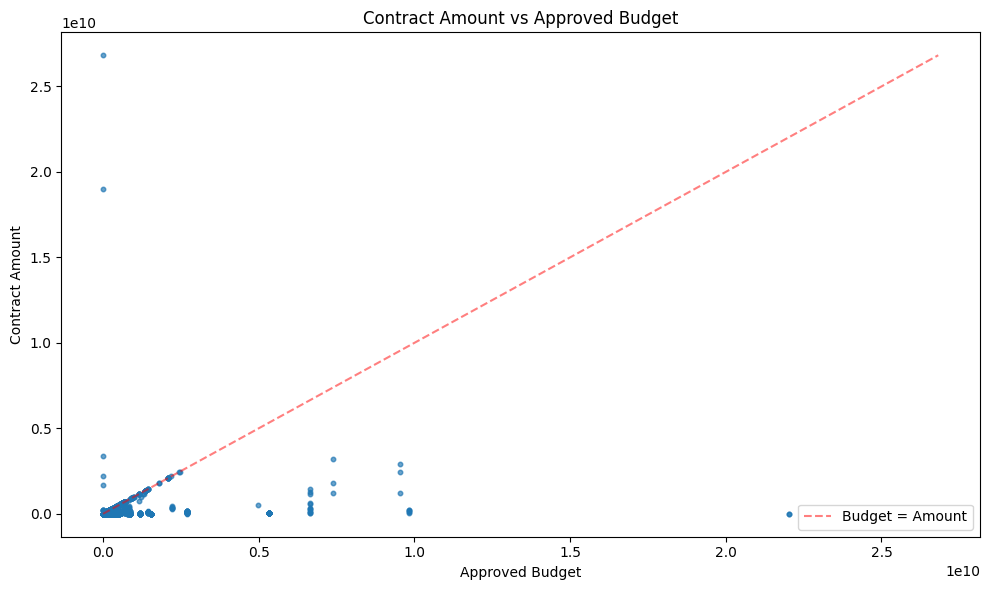

In [82]:
# Contract Amount vs Approved Budget
plt.figure(figsize=(10, 6))
plt.scatter(
    df_explore['Approved Budget of the Contract'], 
    df_explore['Contract Amount'],
    alpha=0.3, s=10
)
max_val = max(
    df_explore['Approved Budget of the Contract'].max(),
    df_explore['Contract Amount'].max()
)
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Budget = Amount')
plt.xlabel('Approved Budget')
plt.ylabel('Contract Amount')
plt.title('Contract Amount vs Approved Budget')
plt.legend()
plt.tight_layout()
plt.show()